In [ ]:
pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.7 MB/s eta 0:00:00


# Stock Analyzer 設定檔
## Member
- self.stocklist : 股票清單
- self.data_store : List，只存符合篩選條件的股票

## 篩選條件
1. 月線大於季線，且股價依然在季線之上(沒有破壞大多頭)，且季線彎頭向上
2. 過去60天內有過一波強勢 (漲幅超過 20%)
3. 拉回幅度 (放寬到 18%，避免像台星科洗盤稍微戳破 15% 就被淘汰)
4. 近期平緩度 (近 5 天的高低區間震幅小於 6%，代表真的在橫盤不跌了)
5. 量縮特徵 (當日成交量必須低於 20日均量，代表洗盤賣壓輕)

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from tqdm import tqdm
import mplfinance as mpf  # 👈 新增這個套件

# 設定中文字型 (避免繪圖亂碼，視作業系統調整)
# plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
# plt.rcParams['axes.unicode_minus'] = False

class TaiwanStockFilter:
    def __init__(self, stock_list):
        # 修正：避免重複添加 .TW 後綴
        # 檢查每個股票代碼是否已經包含 .TW，如果沒有則添加
        self.stock_list = [s if s.endswith('.TW') else f"{s}.TW" for s in stock_list]
        self.data_store = {}

    def fetch_data(self, start_date="2020-01-01", end_date=datetime.now().strftime('%Y-%m-%d')):
        """抓取歷史資料 (往前多抓一點以計算均線)"""
        print(f"正在下載 {len(self.stock_list)} 檔股票資料...")
        for ticker in tqdm(self.stock_list, leave=False): # Add leave=False here
            try:
                # Fetch more data to ensure enough history for MA60 and other features
                df = yf.download(ticker, start=start_date, end=end_date, progress=False)
                if len(df) > 100: # Ensure enough data points for calculations
                    # 處理 MultiIndex Column 問題 (yfinance 新版特性)
                    if isinstance(df.columns, pd.MultiIndex):
                        df.columns = df.columns.get_level_values(0)
                    self.data_store[ticker] = df
            except Exception as e:
                print(f"Error fetching {ticker}: {e}")

    def feature_engineering(self, df):
        """產生特徵"""
        df = df.copy()

        # 1. 基礎均線
        df['MA5'] = df['Close'].rolling(window=5).mean()
        df['MA10'] = df['Close'].rolling(window=10).mean()
        df['MA20'] = df['Close'].rolling(window=20).mean()
        df['MA60'] = df['Close'].rolling(window=60).mean()

        # 新增：季線趨勢 (今天的 60MA 大於 5天前的 60MA，代表季線向上)
        df['MA60_Trend_Up'] = df['MA60'] > df['MA60'].shift(5)

        # 2. 形態特徵：過去 60 天最高價/最低價
        df['High_60d'] = df['High'].rolling(window=60).max()
        df['Low_60d'] = df['Low'].rolling(window=60).min()

        # 3. 強勢上漲特徵 (波段漲幅)
        df['Rally_Magnitude'] = (df['High_60d'] - df['Low_60d']) / df['Low_60d']

        # 4. 拉回幅度 (Drawdown from Peak)
        df['Pullback_Pct'] = (df['High_60d'] - df['Close']) / df['High_60d']

        # ================== 新增特徵 ==================
        # 5. 平台平緩度：近 5 天的高低價差幅度 (判斷是否在橫盤)
        df['High_5d'] = df['High'].rolling(window=5).max()
        df['Low_5d'] = df['Low'].rolling(window=5).min()
        df['Consolidation_Range'] = (df['High_5d'] - df['Low_5d']) / df['Low_5d']

        # 6. 成交量特徵：計算 20 日均量
        df['Vol_MA20'] = df['Volume'].rolling(window=20).mean()

        # 7. 其他技術指標 (RSI)
        delta = df['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        df['RSI'] = 100 - (100 / (1 + rs))

        return df.dropna()

    def check_technical_conditions(self, row):
        """
        修正後的實戰規則篩選:
        """
        # 條件 1: 均線趨勢 (放寬短均線，確保中長線多頭且季線向上)
        # 改為：月線大於季線，且股價依然在季線之上(沒有破壞大多頭)，且季線彎頭向上
        ma_bullish = (row['MA20'] > row['MA60']) and \
                     (row['Close'] > row['MA60']) and \
                     row['MA60_Trend_Up']

        # 條件 2: 過去60天內有過一波強勢 (漲幅超過 20%)
        strong_rally = row['Rally_Magnitude'] > 0.20

        # 條件 3: 拉回幅度 (放寬到 18%，避免像台星科洗盤稍微戳破 15% 就被淘汰)
        pullback_platform = (row['Pullback_Pct'] > 0.02) and (row['Pullback_Pct'] < 0.18)

        # 條件 4: 近期平緩度 (近 5 天的高低區間震幅小於 6%，代表真的在橫盤不跌了)
        flat_consolidation = row['Consolidation_Range'] < 0.06

        # 條件 5: 量縮特徵 (當日成交量必須低於 20日均量，代表洗盤賣壓輕)
        volume_shrink = row['Volume'] < row['Vol_MA20']

        return ma_bullish and strong_rally and pullback_platform and flat_consolidation and volume_shrink

    def find_conforming_stocks(self, as_of_date=None):
        """
        找到符合技術條件的股票
        as_of_date: 指定日期，若為 None 則使用最新資料日期
        """
        conforming_stocks = []
        print("正在篩選符合條件的股票...")
        for ticker, df in tqdm(self.data_store.items()):
            processed_df = self.feature_engineering(df)

            if processed_df.empty:
                continue

            # 取得指定日期或最新一天的資料
            if as_of_date:
                # 找到最接近指定日期且在其之前的資料
                target_date_data = processed_df[processed_df.index <= as_of_date]
                if target_date_data.empty:
                    continue
                latest_row = target_date_data.iloc[-1]
            else:
                latest_row = processed_df.iloc[-1] # 取得最新一天的資料

            if self.check_technical_conditions(latest_row):
                conforming_stocks.append({
                    'Ticker': ticker,
                    'Date': latest_row.name.strftime('%Y-%m-%d'),
                    'Close': latest_row['Close'],
                    'Pullback_Pct': latest_row['Pullback_Pct'] * 100,
                    'Rally_Magnitude': latest_row['Rally_Magnitude'] * 100,
                    'MA5': latest_row['MA5'],
                    'MA10': latest_row['MA10'],
                    'MA20': latest_row['MA20'],
                    'MA60': latest_row['MA60']
                })
        return conforming_stocks

    def plot_pattern(self, ticker, date):
        """畫出特定日期的K線圖，驗證形態"""
        df = self.data_store[ticker]
        processed_df = self.feature_engineering(df) # Apply feature engineering here

        target_date = pd.Timestamp(date)
        start_plot = target_date - pd.Timedelta(days=80) # 看前80天
        end_plot = target_date + pd.Timedelta(days=20)   # 看後20天

        subset = processed_df[(processed_df.index >= start_plot) & (processed_df.index <= end_plot)]

        plt.figure(figsize=(10, 6))
        plt.plot(subset.index, subset['Close'], label='Close Price')
        plt.plot(subset.index, subset['MA5'], label='MA5', linestyle='-') # Add MA5 line
        plt.plot(subset.index, subset['MA20'], label='MA20', linestyle='--')
        plt.plot(subset.index, subset['MA60'], label='MA60', linestyle='--')

        # 標記訊號點
        if target_date in subset.index:
            price = subset.loc[target_date]['Close']
            plt.scatter(target_date, price, color='red', s=100, zorder=5, label='Signal Date')

        plt.title(f"{ticker} - Signal at {date}")
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_candlestick(self, ticker, target_date=None, days_before=80, days_after=20):
        """
        畫出包含 K 棒與成交量的專業技術線圖。
        即使股票被過濾掉，或原本不在清單內，也能即時下載並畫圖。
        """
        # 1. 確保股票代號有 .TW
        ticker = ticker if ticker.endswith('.TW') else f"{ticker}.TW"

        # 2. 取得資料：先找 data_store，找不到就當場下載
        if ticker in self.data_store:
            print(f"📊 從暫存中讀取 {ticker} 資料...")
            df = self.data_store[ticker]
        else:
            print(f"🔍 {ticker} 不在暫存中，正在即時下載資料...")
            # 往前多抓 200 天，確保有足夠的資料算 60MA
            end_date = pd.Timestamp.now()
            start_date = end_date - pd.Timedelta(days=200)
            df = yf.download(ticker, start=start_date, end=end_date, progress=False)

            if df.empty:
                print(f"❌ 無法下載 {ticker} 的資料，請確認代號是否正確。")
                return

            # 處理 MultiIndex Column 問題 (yfinance 新版特性)
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)

        # 3. 計算均線與特徵 (共用您寫好的 feature_engineering)
        processed_df = self.feature_engineering(df)

        # 4. 決定畫圖的時間範圍
        if target_date:
            t_date = pd.Timestamp(target_date)
        else:
            t_date = processed_df.index[-1] # 沒指定日期，就看最新的一天

        start_plot = t_date - pd.Timedelta(days=days_before)
        end_plot = t_date + pd.Timedelta(days=days_after)

        subset = processed_df[(processed_df.index >= start_plot) & (processed_df.index <= end_plot)]

        if subset.empty:
            print(f"❌ 在指定的時間範圍內找不到 {ticker} 的資料。")
            return

        # ==========================================
        # 5. 使用 mplfinance 畫出超美 K 線圖
        # ==========================================
        # 設定台股專用顏色：紅漲、綠跌 (美股預設是綠漲紅跌)
        mc = mpf.make_marketcolors(up='r', down='g', edge='inherit', wick='inherit', volume='in')
        # 設定圖表風格
        s  = mpf.make_mpf_style(marketcolors=mc, gridstyle=':', y_on_right=False)

        # 將 MA5, MA20, MA60 加入圖表疊加顯示
        ap = [
            mpf.make_addplot(subset['MA5'], color='blue', width=1.5, panel=0),
            mpf.make_addplot(subset['MA20'], color='orange', width=1.5, panel=0),
            mpf.make_addplot(subset['MA60'], color='purple', width=1.5, panel=0)
        ]

        # 執行畫圖 (包含成交量副圖)
        mpf.plot(subset,
                 type='candle',        # 指定畫 K 棒
                 addplot=ap,           # 疊加均線
                 volume=True,          # 顯示成交量
                 style=s,              # 套用台股顏色風格
                 title=f"\n{ticker} Candlestick Chart",
                 figsize=(12, 8))


# 執行區塊

In [ ]:
# ==========================================
# 執行區塊
# ==========================================

# 由於 'sample_stocks' 變數未定義，因此在此提供一個範例列表。
# 這通常用於示範或測試目的。
# 在實際應用中，這個列表可能來自外部檔案、API 或資料庫。
sample_stocks = [
    '2330.TW', '2454.TW', '2317.TW', '2881.TW', '2882.TW', '2886.TW', '2891.TW', '2885.TW', '3711.TW', '2303.TW',
    '2002.TW', '1301.TW', '1303.TW', '6505.TW', '1216.TW', '1402.TW', '1101.TW', '2207.TW', '2308.TW', '2603.TW',
    '2609.TW', '2610.TW', '2615.TW', '2801.TW', '2823.TW', '2880.TW', '2884.TW', '2887.TW', '2892.TW', '3008.TW',
    '3045.TW', '3481.TW', '4938.TW', '5871.TW', '5876.TW', '5880.TW', '6415.TW', '6669.TW', '6770.TW', '9904.TW',
    '9910.TW', '9939.TW', '9945.TW', '1707.TW', '1802.TW', '2301.TW', '2357.TW', '2382.TW', '2408.TW', '1590.TW', "3265.TW"
]

# 1. 定義 0050 成分股作為範例
# 使用 kernel 中已有的 sample_stocks 變數，作為 0050 成分股的範例
_0050_sample_constituents = sample_stocks

# 初始化分析器
stock_filter = TaiwanStockFilter(_0050_sample_constituents)

# 下載資料 (設置 end_date 為今天，以獲取最新數據進行篩選)
stock_filter.fetch_data(start_date="2020-01-01", end_date=datetime.now().strftime('%Y-%m-%d'))

# 找到符合條件的股票
# 使用最新資料進行篩選 (as_of_date=None)
filtered_stocks = stock_filter.find_conforming_stocks()

# 顯示結果
if filtered_stocks:
    print("\n=== 符合條件的 0050 範例成分股 ===")
    print(f"{'代號':<10} {'日期':<12} {'收盤價':<8} {'拉回幅度%':<12} {'波段漲幅%':<12} {'MA5':<8} {'MA10':<8} {'MA20':<8} {'MA60':<8}")
    print("-" * 90)
    for stock in filtered_stocks:
        print(f"{stock['Ticker']:<10} {stock['Date']:<12} {stock['Close']:.1f}     {stock['Pullback_Pct']:.2f}%      {stock['Rally_Magnitude']:.2f}%      {stock['MA5']:.1f}    {stock['MA10']:.1f}    {stock['MA20']:.1f}    {stock['MA60']:.1f}")
else:
    print("沒有找到符合條件的 0050 範例成分股。")

正在下載 51 檔股票資料...


  0%|          | 0/51 [00:00<?, ?it/s]/tmp/ipython-input-3392615326.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipython-input-3392615326.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipython-input-3392615326.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)
  6%|▌         | 3/51 [00:00<00:01, 24.09it/s]/tmp/ipython-input-3392615326.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipython-input-3392615326.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_da

正在篩選符合條件的股票...


100%|██████████| 49/49 [00:00<00:00, 94.51it/s]


=== 符合條件的 0050 範例成分股 ===
代號         日期           收盤價      拉回幅度%        波段漲幅%        MA5      MA10     MA20     MA60    
------------------------------------------------------------------------------------------
2002.TW    2026-02-11   20.9     3.24%      22.73%      20.6    20.7    20.0    19.1
1101.TW    2026-02-11   25.8     4.27%      33.09%      25.6    25.8    25.8    23.7


In [ ]:
stock_filter.plot_pattern('3265.TW', '2026-02-11')

KeyError: '3265.TW'

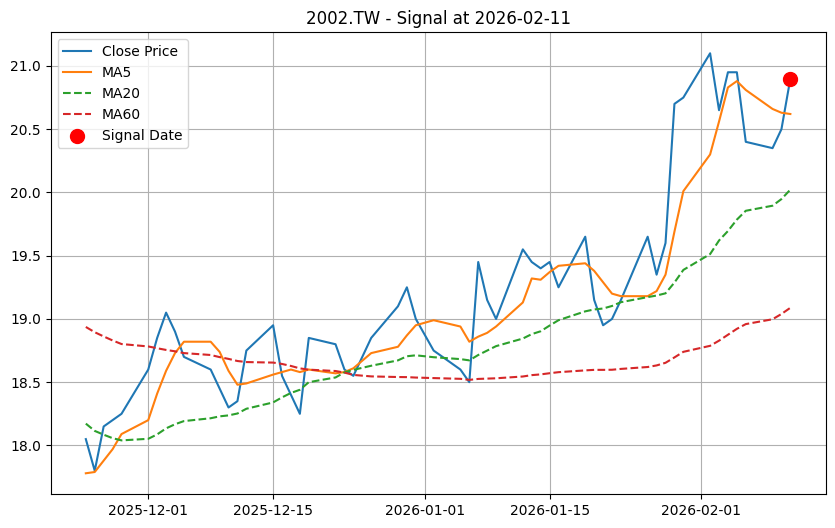

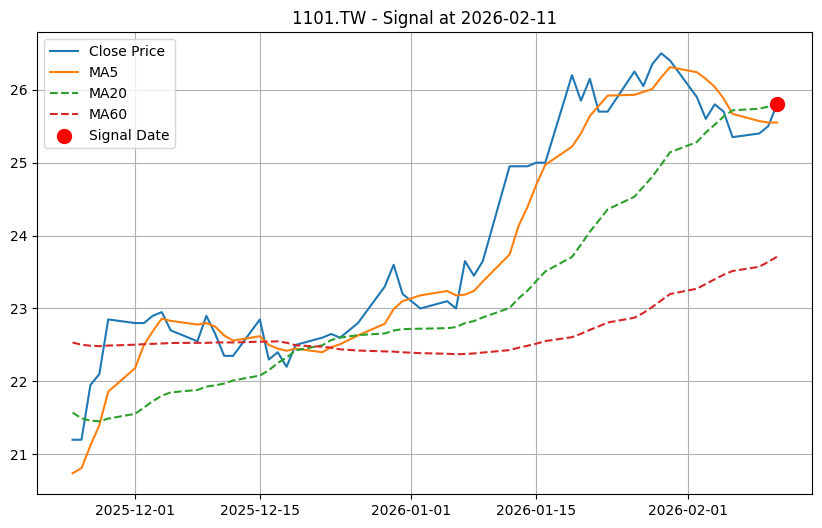

In [ ]:
for stock in filtered_stocks:
    stock_filter.plot_pattern(stock['Ticker'], stock['Date'])

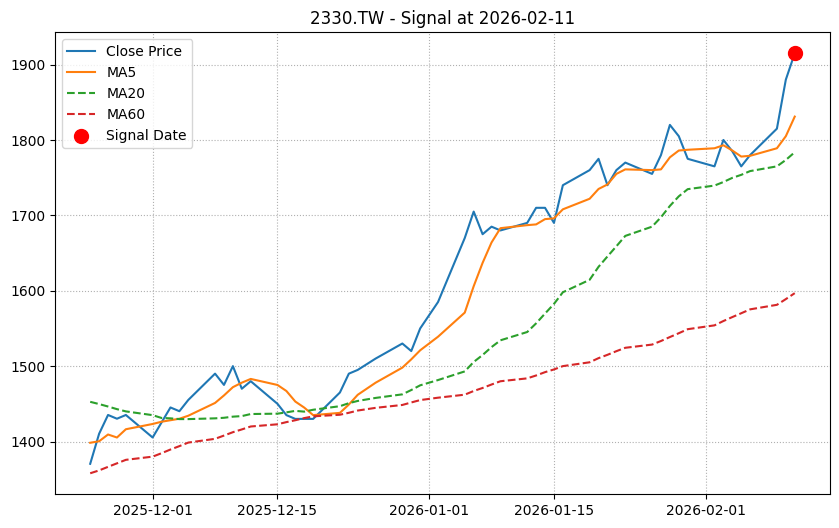

📊 從暫存中讀取 2330.TW 資料...


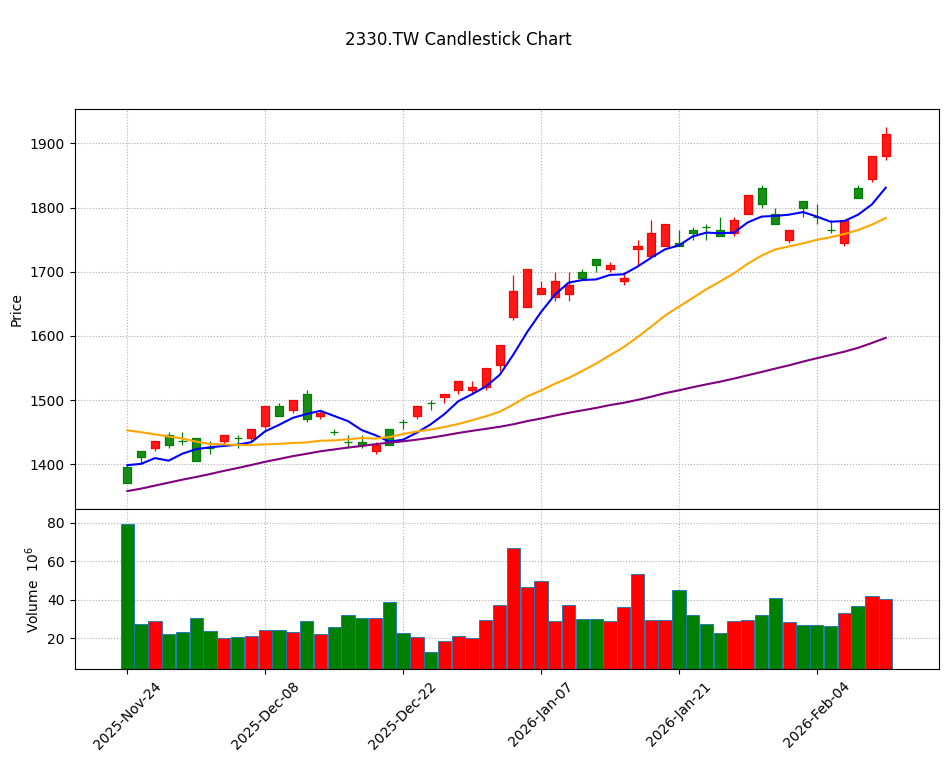

In [ ]:
stock_filter.plot_pattern('2330.TW', '2026-02-11')
stock_filter.plot_candlestick('2330')

📊 從暫存中讀取 2002.TW 資料...


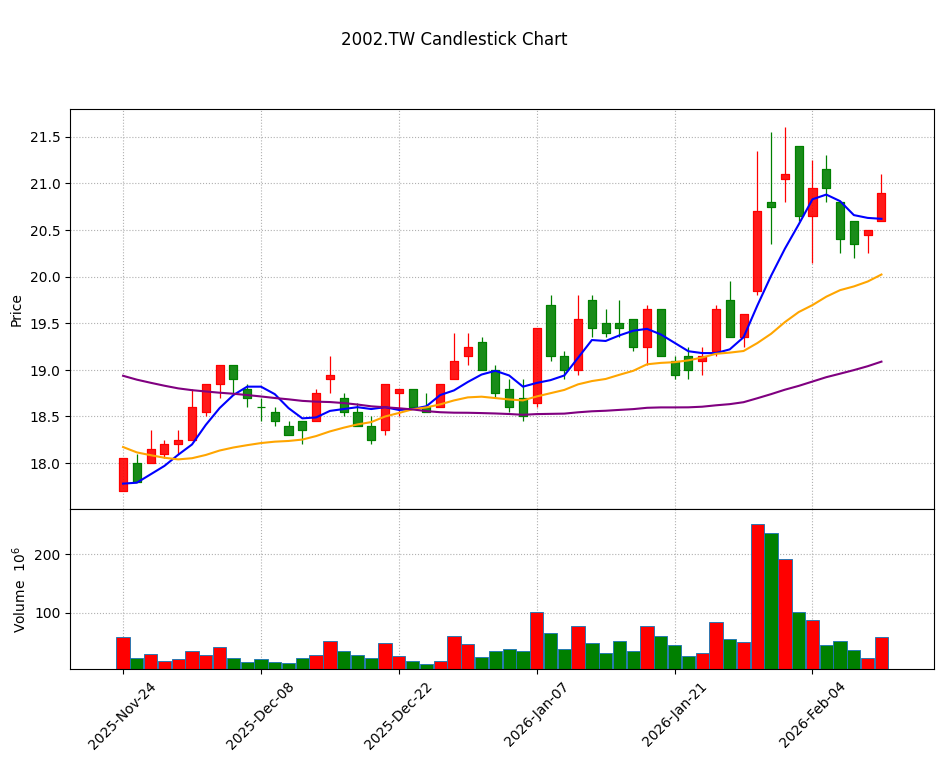

📊 從暫存中讀取 1101.TW 資料...


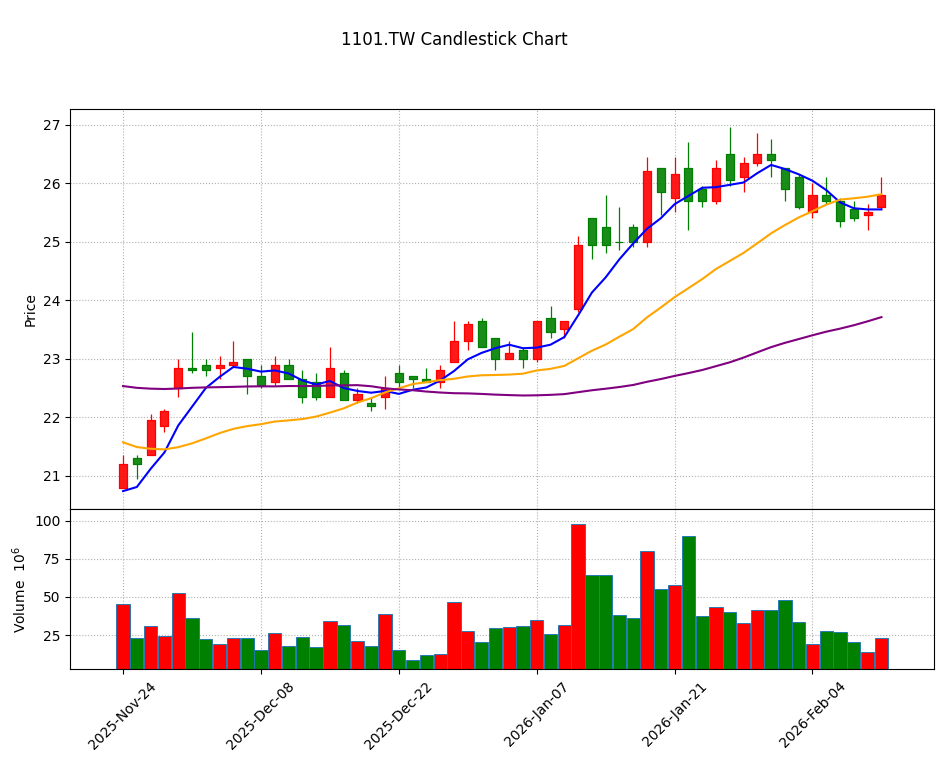

In [ ]:
for stock in filtered_stocks:
    stock_filter.plot_candlestick(stock['Ticker'], stock['Date'])